# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

Prepared as a self-contained submission notebook for the Wisconsin Diagnostic Breast Cancer classification experiment.
"""))


# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

Prepared as a self-contained submission notebook for the Wisconsin Diagnostic Breast Cancer classification experiment.


## Aim

In [2]:
display(Markdown("""**Aim:** Study the effect of Principal Component Analysis (PCA) on classifier performance by training and tuning ten models (SVM, Naive Bayes, KNN, Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, Stacking) on the Wisconsin Diagnostic Breast Cancer dataset, both in the original feature space and in a PCA-reduced feature space, and compare accuracy, F1-score, and fold-to-fold stability between the two settings."""))

**Aim:** Study the effect of Principal Component Analysis (PCA) on classifier performance by training and tuning ten models (SVM, Naive Bayes, KNN, Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, Stacking) on the Wisconsin Diagnostic Breast Cancer dataset, both in the original feature space and in a PCA-reduced feature space, and compare accuracy, F1-score, and fold-to-fold stability between the two settings.

## Objective

In [3]:
display(Markdown("""
**Objectives**
- Reuse the EDA notebook for dataset loading, preprocessing, and train-test split.
- Apply PCA on the standardized features and choose the number of components using a 95% explained-variance target, with a scree plot to justify the choice.
- Define a hyperparameter search grid for each of the ten required models.
- Train and tune every model twice: once on the original (No-PCA) feature space and once on the PCA-reduced (With-PCA) feature space, using 5-fold cross-validation for both.
- Record fold-wise and average CV accuracy/F1 for every model under both settings.
- Evaluate tuned models on the held-out test set with Accuracy, Precision, Recall, F1, ROC-AUC, and confusion matrices for representative models.
- Build a Stacked Ensemble (SVM + Random Forest + Gradient Boosting base learners, Logistic Regression meta-learner) under both settings.
- Analyze whether PCA improved accuracy, F1-score, or stability for each model family, and produce the required plots, tables, observations, and conclusion.
"""))


**Objectives**
- Reuse the EDA notebook for dataset loading, preprocessing, and train-test split.
- Apply PCA on the standardized features and choose the number of components using a 95% explained-variance target, with a scree plot to justify the choice.
- Define a hyperparameter search grid for each of the ten required models.
- Train and tune every model twice: once on the original (No-PCA) feature space and once on the PCA-reduced (With-PCA) feature space, using 5-fold cross-validation for both.
- Record fold-wise and average CV accuracy/F1 for every model under both settings.
- Evaluate tuned models on the held-out test set with Accuracy, Precision, Recall, F1, ROC-AUC, and confusion matrices for representative models.
- Build a Stacked Ensemble (SVM + Random Forest + Gradient Boosting base learners, Logistic Regression meta-learner) under both settings.
- Analyze whether PCA improved accuracy, F1-score, or stability for each model family, and produce the required plots, tables, observations, and conclusion.


## Brief Theory

In [4]:
display(Markdown("""
**Brief Theory**
- **Principal Component Analysis (PCA)** is an unsupervised linear transformation that projects standardized features onto orthogonal directions (principal components) ordered by the variance they explain. Keeping only the components needed to reach a target explained-variance ratio (95% here) reduces dimensionality while discarding the least informative, most redundant directions in the data.
- PCA tends to help models that are sensitive to correlated/redundant features and to the curse of dimensionality in distance or margin computations (KNN, SVM, Logistic Regression), because it removes multicollinearity and shrinks the feature space the model has to search.
- PCA can hurt or make little difference for models that already handle high-dimensional, correlated features robustly through their own internal feature selection (tree-based models: Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost), since these models pick informative splits directly and the PCA transform can obscure the original feature meaning that made those splits effective.
- Stacking combines heterogeneous base learners with a meta-learner; because it inherits the behavior of its base learners, its sensitivity to PCA should track the average sensitivity of the models it stacks.
- 5-fold cross-validation with `GridSearchCV` is used throughout so that hyperparameters are chosen using held-out performance instead of training-set fit alone, for both the No-PCA and With-PCA feature spaces.
"""))


**Brief Theory**
- **Principal Component Analysis (PCA)** is an unsupervised linear transformation that projects standardized features onto orthogonal directions (principal components) ordered by the variance they explain. Keeping only the components needed to reach a target explained-variance ratio (95% here) reduces dimensionality while discarding the least informative, most redundant directions in the data.
- PCA tends to help models that are sensitive to correlated/redundant features and to the curse of dimensionality in distance or margin computations (KNN, SVM, Logistic Regression), because it removes multicollinearity and shrinks the feature space the model has to search.
- PCA can hurt or make little difference for models that already handle high-dimensional, correlated features robustly through their own internal feature selection (tree-based models: Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost), since these models pick informative splits directly and the PCA transform can obscure the original feature meaning that made those splits effective.
- Stacking combines heterogeneous base learners with a meta-learner; because it inherits the behavior of its base learners, its sensitivity to PCA should track the average sensitivity of the models it stacks.
- 5-fold cross-validation with `GridSearchCV` is used throughout so that hyperparameters are chosen using held-out performance instead of training-set fit alone, for both the No-PCA and With-PCA feature spaces.


## Import Libraries

In [5]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 4)

## Configuration

In [6]:
DATASET_NAME = "Wisconsin Diagnostic Breast Cancer"
TARGET_COLUMN = "diagnosis"
RANDOM_STATE = 42
TEST_SIZE = 0.2
EDA_NOTEBOOK_PATH = "../Ass1/EDA_Pipeline.ipynb"
OUTPUT_DIRECTORY = "experiment7_output"
PLOTS_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "plots")
EDA_OUTPUT_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "eda_reuse")
LOCAL_BREAST_CANCER_CSV = "breast_cancer.csv"
UCI_REFERENCE = "https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic"
PCA_VARIANCE_TARGET = 0.95

os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)
os.makedirs(PLOTS_DIRECTORY, exist_ok=True)


def resolve_breast_cancer_csv():
    candidate = Path(LOCAL_BREAST_CANCER_CSV)
    if candidate.exists():
        return str(candidate)
    data = load_breast_cancer(as_frame=True)
    frame = data.frame.copy()
    frame[TARGET_COLUMN] = frame["target"].map(dict(enumerate(["M", "B"])))
    frame = frame.drop(columns=["target"])
    frame.to_csv(candidate, index=False)
    return str(candidate)


CSV_PATH = resolve_breast_cancer_csv()
OUTPUT_DIRECTORY = EDA_OUTPUT_DIRECTORY
print(f"Dataset path resolved to: {CSV_PATH}")
print(f"EDA notebook path: {EDA_NOTEBOOK_PATH}")
print(f"Experiment output directory: {Path(PLOTS_DIRECTORY).resolve()}")
print(f"UCI reference: {UCI_REFERENCE}")
print("Note: this is the same Wisconsin Diagnostic Breast Cancer dataset used in Experiments 5 and 6.")

Dataset path resolved to: breast_cancer.csv
EDA notebook path: ../Ass1/EDA_Pipeline.ipynb
Experiment output directory: /Users/vijayaraaghavanks/Dev/college/SEM-5/ML/Ass7/experiment7_output/plots
UCI reference: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
Note: this is the same Wisconsin Diagnostic Breast Cancer dataset used in Experiments 5 and 6.


## Run EDA Notebook

Dataset: Wisconsin Diagnostic Breast Cancer
Shape: (569, 31)
Rows: 569
Columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,M
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,M
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,M
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,M
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,M


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
204,12.47,18.60,81.09,481.9,0.0997,0.1058,0.0800,0.0382,0.1925,0.0637,...,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,B
70,18.94,21.31,123.60,1130.0,0.0901,0.1029,0.1080,0.0795,0.1582,0.0546,...,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.1789,0.2551,0.0659,M
131,15.46,19.48,101.70,748.9,0.1092,0.1223,0.1466,0.0809,0.1931,0.0580,...,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.1514,0.2837,0.0802,M
431,12.40,17.68,81.47,467.8,0.1054,0.1316,0.0774,0.0280,0.1811,0.0710,...,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.0737,0.2556,0.0936,B
540,11.54,14.44,74.65,402.9,0.0998,0.1120,0.0674,0.0259,0.1818,0.0678,...,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.0692,0.2329,0.0813,B


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,16.2692,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,4.8332,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,7.9300,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,13.0100,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,14.9700,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,18.7900,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921
max,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,...,36.0400,49.5400,251.2000,4254.0000,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,357
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839,NaN
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181,NaN
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550,NaN
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715,NaN
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800,NaN
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921,NaN


Numerical features: 30
Categorical features: 0
Target type: Categorical
ML task: classification
Duplicate rows: 0
Constant columns: None


,dtype,missing_count,missing_%,unique_values,constant
mean radius,float64,0,0.0,456,False
mean texture,float64,0,0.0,479,False
mean perimeter,float64,0,0.0,522,False
mean area,float64,0,0.0,539,False
mean smoothness,float64,0,0.0,474,False
mean compactness,float64,0,0.0,537,False
mean concavity,float64,0,0.0,537,False
mean concave points,float64,0,0.0,542,False
mean symmetry,float64,0,0.0,432,False
mean fractal dimension,float64,0,0.0,499,False


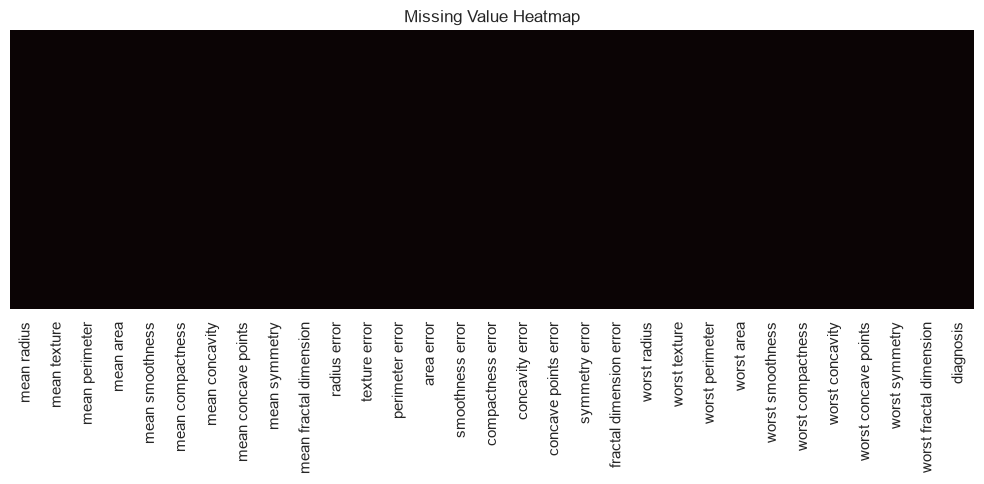

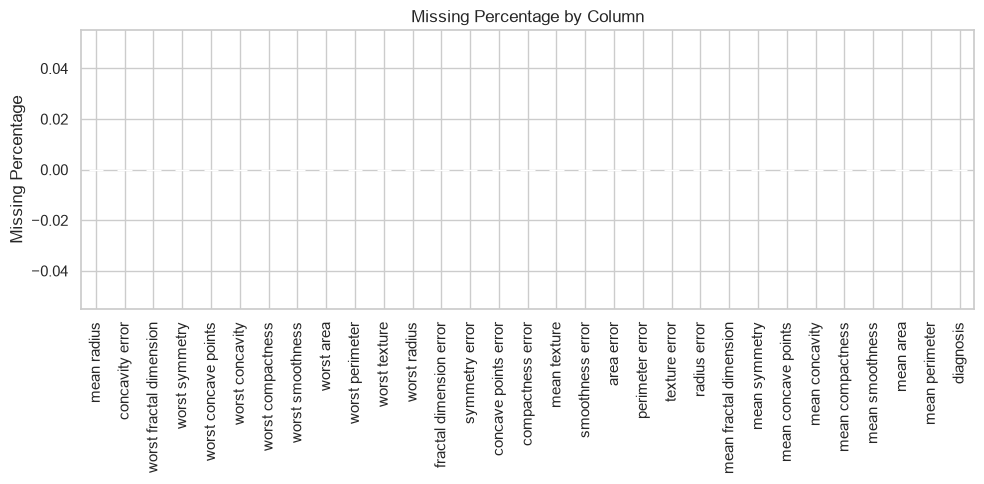

,column,missing_%
0,mean radius,0.0
1,concavity error,0.0
2,worst fractal dimension,0.0
3,worst symmetry,0.0
4,worst concave points,0.0
5,worst concavity,0.0
6,worst compactness,0.0
7,worst smoothness,0.0
8,worst area,0.0
9,worst perimeter,0.0


,feature,iqr_lower,iqr_upper,iqr_outliers,z_score_outliers
0,mean radius,5.5800,21.9000,14,5
1,mean texture,7.7250,30.2450,7,4
2,mean perimeter,31.7750,147.4950,13,7
3,mean area,-123.3000,1326.3000,25,8
4,mean smoothness,0.0580,0.1337,6,5
5,mean compactness,-0.0333,0.2286,16,9
6,mean concavity,-0.1222,0.2824,18,9
7,mean concave points,-0.0602,0.1545,10,6
8,mean symmetry,0.1112,0.2464,15,5
9,mean fractal dimension,0.0451,0.0787,15,7


mean radius: IQR=14, Z-score=5
mean texture: IQR=7, Z-score=4
mean perimeter: IQR=13, Z-score=7
mean area: IQR=25, Z-score=8
mean smoothness: IQR=6, Z-score=5
mean compactness: IQR=16, Z-score=9
mean concavity: IQR=18, Z-score=9
mean concave points: IQR=10, Z-score=6
mean symmetry: IQR=15, Z-score=5
mean fractal dimension: IQR=15, Z-score=7
radius error: IQR=38, Z-score=7
texture error: IQR=20, Z-score=9
perimeter error: IQR=38, Z-score=8
area error: IQR=65, Z-score=6
smoothness error: IQR=30, Z-score=7
compactness error: IQR=28, Z-score=12
concavity error: IQR=22, Z-score=6
concave points error: IQR=19, Z-score=6
symmetry error: IQR=27, Z-score=11
fractal dimension error: IQR=28, Z-score=10
worst radius: IQR=17, Z-score=6
worst texture: IQR=5, Z-score=4
worst perimeter: IQR=15, Z-score=6
worst area: IQR=35, Z-score=10
worst smoothness: IQR=7, Z-score=3
worst compactness: IQR=16, Z-score=10
worst concavity: IQR=12, Z-score=7
worst concave points: IQR=0, Z-score=0
worst symmetry: IQR=23

,feature,test,statistic,p_value,normal
0,mean radius,Shapiro,0.9411,3.1056e-14,False
1,mean texture,Shapiro,0.9767,7.2836e-08,False
2,mean perimeter,Shapiro,0.9362,7.0114e-15,False
3,mean area,Shapiro,0.8584,3.1963e-22,False
4,mean smoothness,Shapiro,0.9875,8.6008e-05,False
5,mean compactness,Shapiro,0.9170,3.9672e-17,False
6,mean concavity,Shapiro,0.8668,1.3386e-21,False
7,mean concave points,Shapiro,0.8917,1.4046e-19,False
8,mean symmetry,Shapiro,0.9726,7.8848e-09,False
9,mean fractal dimension,Shapiro,0.9233,1.9566e-16,False


,feature,test,statistic,p_value
0,mean radius,ANOVA,646.9810,8.4659e-96
1,mean texture,ANOVA,118.0961,4.0586e-25
2,mean perimeter,ANOVA,697.2353,8.4363e-101
3,mean area,ANOVA,573.0607,4.7346e-88
4,mean smoothness,ANOVA,83.6511,1.0519e-18
5,mean compactness,ANOVA,313.2331,3.9383e-56
6,mean concavity,ANOVA,533.7931,9.9666e-84
7,mean concave points,ANOVA,861.6760,7.1012e-116
8,mean symmetry,ANOVA,69.5274,5.7334e-16
9,mean fractal dimension,ANOVA,0.0935,7.5994e-01


**Pearson Correlation Matrix**

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.0000,0.3238,0.9979,0.9874,0.1706,0.5061,0.6768,0.8225,0.1477,-0.3116,...,0.9695,0.2970,0.9651,0.9411,0.1196,0.4135,0.5269,0.7442,0.1640,0.0071
mean texture,0.3238,1.0000,0.3295,0.3211,-0.0234,0.2367,0.3024,0.2935,0.0714,-0.0764,...,0.3526,0.9120,0.3580,0.3435,0.0775,0.2778,0.3010,0.2953,0.1050,0.1192
mean perimeter,0.9979,0.3295,1.0000,0.9865,0.2073,0.5569,0.7161,0.8510,0.1830,-0.2615,...,0.9695,0.3030,0.9704,0.9415,0.1505,0.4558,0.5639,0.7712,0.1891,0.0510
mean area,0.9874,0.3211,0.9865,1.0000,0.1770,0.4985,0.6860,0.8233,0.1513,-0.2831,...,0.9627,0.2875,0.9591,0.9592,0.1235,0.3904,0.5126,0.7220,0.1436,0.0037
mean smoothness,0.1706,-0.0234,0.2073,0.1770,1.0000,0.6591,0.5220,0.5537,0.5578,0.5848,...,0.2131,0.0361,0.2389,0.2067,0.8053,0.4725,0.4349,0.5031,0.3943,0.4993
mean compactness,0.5061,0.2367,0.5569,0.4985,0.6591,1.0000,0.8831,0.8311,0.6026,0.5654,...,0.5353,0.2481,0.5902,0.5096,0.5655,0.8658,0.8163,0.8156,0.5102,0.6874
mean concavity,0.6768,0.3024,0.7161,0.6860,0.5220,0.8831,1.0000,0.9214,0.5007,0.3368,...,0.6882,0.2999,0.7296,0.6760,0.4488,0.7550,0.8841,0.8613,0.4095,0.5149
mean concave points,0.8225,0.2935,0.8510,0.8233,0.5537,0.8311,0.9214,1.0000,0.4625,0.1669,...,0.8303,0.2928,0.8559,0.8096,0.4528,0.6675,0.7524,0.9102,0.3757,0.3687
mean symmetry,0.1477,0.0714,0.1830,0.1513,0.5578,0.6026,0.5007,0.4625,1.0000,0.4799,...,0.1857,0.0907,0.2192,0.1772,0.4267,0.4732,0.4337,0.4303,0.6998,0.4384
mean fractal dimension,-0.3116,-0.0764,-0.2615,-0.2831,0.5848,0.5654,0.3368,0.1669,0.4799,1.0000,...,-0.2537,-0.0513,-0.2052,-0.2319,0.5049,0.4588,0.3462,0.1753,0.3340,0.7673


**Spearman Correlation Matrix**

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.0000,0.3410,0.9978,0.9996,0.1485,0.4976,0.6457,0.7597,0.1202,-0.3499,...,0.9786,0.3149,0.9716,0.9789,0.1258,0.4914,0.5960,0.7273,0.1747,0.0446
mean texture,0.3410,1.0000,0.3481,0.3441,0.0246,0.2665,0.3426,0.3069,0.1101,-0.0593,...,0.3665,0.9092,0.3753,0.3683,0.1014,0.2909,0.3397,0.3192,0.1207,0.1161
mean perimeter,0.9978,0.3481,1.0000,0.9971,0.1829,0.5439,0.6820,0.7886,0.1500,-0.3049,...,0.9812,0.3231,0.9790,0.9809,0.1566,0.5346,0.6321,0.7575,0.1990,0.0890
mean area,0.9996,0.3441,0.9971,1.0000,0.1381,0.4890,0.6426,0.7552,0.1139,-0.3584,...,0.9793,0.3182,0.9718,0.9803,0.1197,0.4858,0.5937,0.7234,0.1709,0.0388
mean smoothness,0.1485,0.0246,0.1829,0.1381,1.0000,0.6788,0.5185,0.5652,0.5422,0.5885,...,0.2035,0.0606,0.2263,0.1917,0.7961,0.4814,0.4291,0.4989,0.3936,0.5115
mean compactness,0.4976,0.2665,0.5439,0.4890,0.6788,1.0000,0.8965,0.8483,0.5522,0.4992,...,0.5426,0.2553,0.5923,0.5316,0.5789,0.9010,0.8379,0.8255,0.4503,0.6890
mean concavity,0.6457,0.3426,0.6820,0.6426,0.5185,0.8965,1.0000,0.9274,0.4468,0.2582,...,0.6823,0.3359,0.7224,0.6766,0.4888,0.8500,0.9385,0.9049,0.3837,0.5418
mean concave points,0.7597,0.3069,0.7886,0.7552,0.5652,0.8483,0.9274,1.0000,0.4238,0.1427,...,0.7874,0.3006,0.8140,0.7804,0.4900,0.7583,0.8273,0.9371,0.3555,0.4211
mean symmetry,0.1202,0.1101,0.1500,0.1139,0.5422,0.5522,0.4468,0.4238,1.0000,0.4285,...,0.1646,0.1189,0.1905,0.1545,0.4242,0.4408,0.3945,0.3975,0.7104,0.4101
mean fractal dimension,-0.3499,-0.0593,-0.3049,-0.3584,0.5885,0.4992,0.2582,0.1427,0.4285,1.0000,...,-0.2945,-0.0478,-0.2475,-0.3049,0.4935,0.4037,0.2426,0.1392,0.2950,0.7608


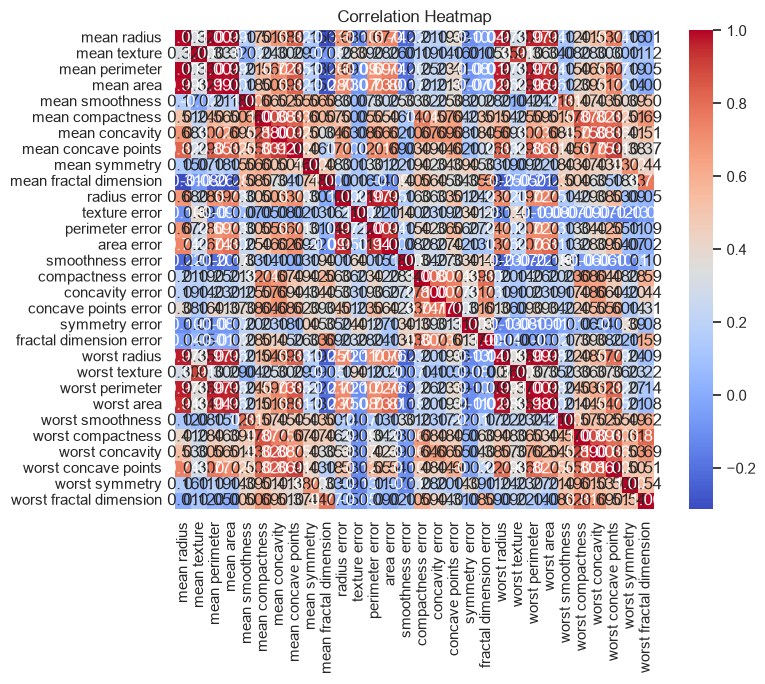

Highly correlated pairs: 44


,feature_1,feature_2,correlation
0,mean radius,mean perimeter,0.9979
1,mean radius,mean area,0.9874
2,mean radius,mean concave points,0.8225
3,mean radius,worst radius,0.9695
4,mean radius,worst perimeter,0.9651
5,mean radius,worst area,0.9411
6,mean texture,worst texture,0.9120
7,mean perimeter,mean area,0.9865
8,mean perimeter,mean concave points,0.8510
9,mean perimeter,worst radius,0.9695


,diagnosis,count
0,B,357
1,M,212


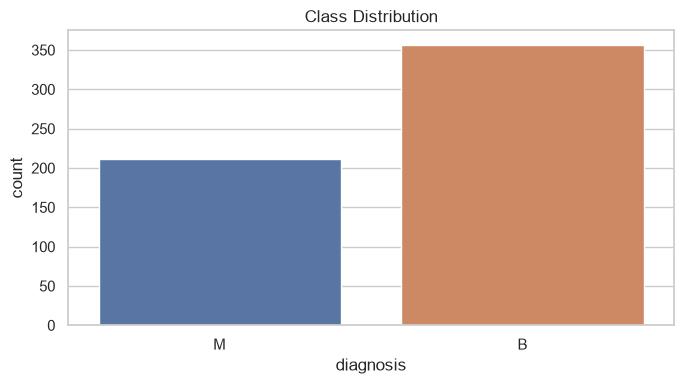

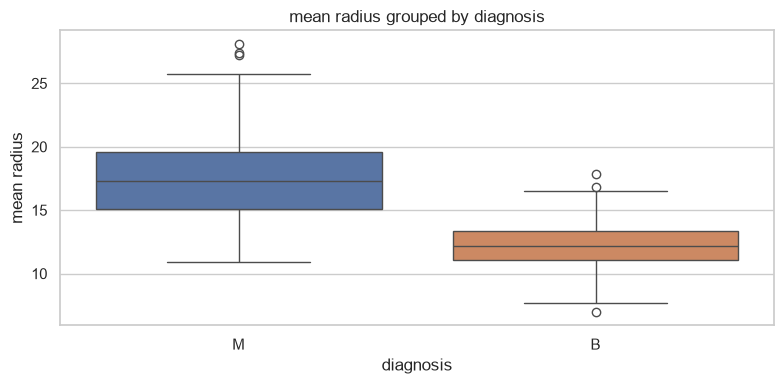

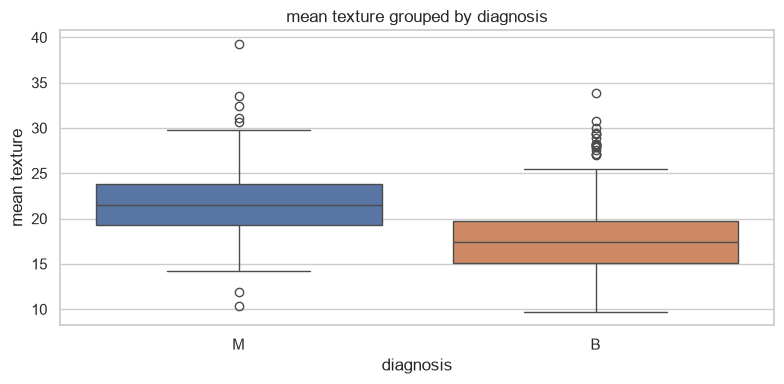

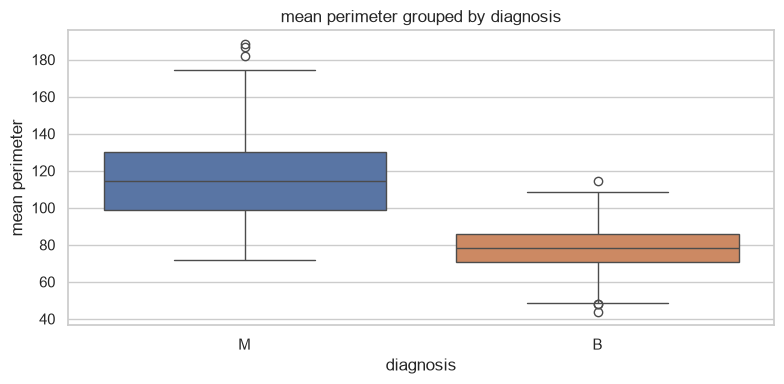

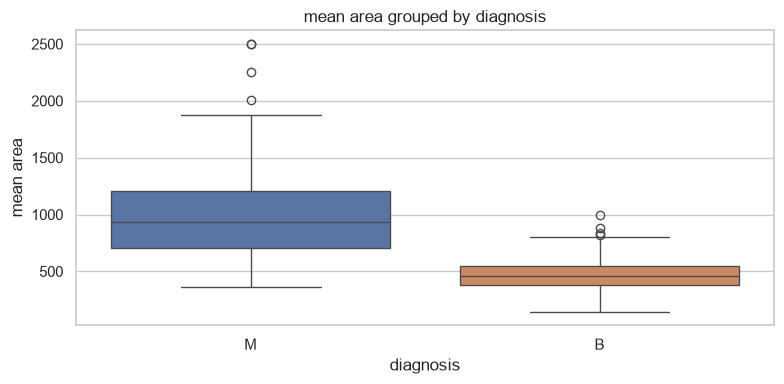

Training shape: (455, 30)
Testing shape: (114, 30)
Encoded features: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
10,0.5186,0.8918,0.4246,0.3839,-0.9747,-0.6898,-0.6886,-0.3982,-1.0392,-0.8251,...,0.5798,1.3132,0.4669,0.4460,-0.5962,-0.6347,-0.6102,-0.2357,0.0546,0.0218
170,-0.5164,-1.6397,-0.5413,-0.5430,0.4762,-0.6318,-0.6043,-0.3031,0.5215,-0.4545,...,-0.5825,-1.6903,-0.6119,-0.5870,0.2736,-0.8148,-0.7127,-0.3232,-0.1376,-0.9044
407,-0.3681,0.4555,-0.3882,-0.4030,-1.4330,-0.3839,-0.3422,-0.7655,-0.8509,-0.2262,...,-0.3986,0.1820,-0.4754,-0.4208,-1.6228,-0.3914,-0.4313,-0.8908,-0.6759,-0.1440
430,0.2053,0.7262,0.4003,0.0706,0.2433,2.2036,2.2561,1.2132,0.8185,0.8998,...,-0.0003,0.2742,0.5138,-0.0995,0.4185,2.8660,2.9586,1.9771,-0.0756,1.7288
27,1.2430,0.1942,1.2104,1.2067,-0.1114,0.0513,0.7330,0.7138,-0.4272,-0.8222,...,1.0128,0.2231,0.9385,0.8809,0.0732,-0.2770,0.3278,0.5019,-0.9093,-0.5462


,feature,select_k_best_score,p_value,mutual_information
20,worst radius,692.8614,2.4837e-93,0.4612
22,worst perimeter,717.2465,2.0930e-95,0.4546
23,worst area,522.1889,1.9324e-77,0.4533
7,mean concave points,684.5268,1.3009e-92,0.4460
27,worst concave points,733.7249,8.7786e-97,0.4329
2,mean perimeter,548.4132,4.6875e-80,0.4093
3,mean area,444.8575,2.6912e-69,0.3747
0,mean radius,511.2748,2.4851e-76,0.3733
6,mean concavity,397.5921,5.7819e-64,0.3541
13,area error,180.5612,6.9984e-35,0.3500


,component,explained_variance_ratio
0,PC1,0.4459
1,PC2,0.1855


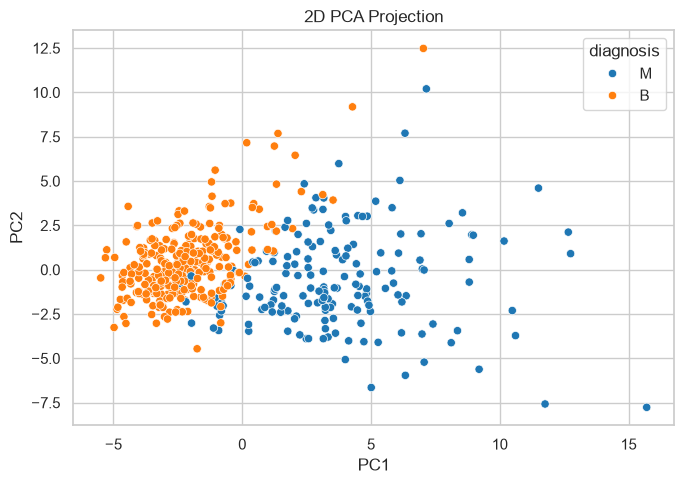

Dataset contains 569 samples and 31 columns.
Detected 30 numerical features and 0 categorical features.
Target column `diagnosis` is treated as Categorical; task type is classification.
Duplicate rows: 0.
Columns with missing values: 0.
Highly correlated feature pairs: 44.
Constant features: None.
Suggested models: Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, SVM.
Report saved to: experiment7_output/eda_reuse/eda_report.md
Plots saved to: experiment7_output/eda_reuse/plots


In [7]:
get_ipython().run_line_magic('run', '$EDA_NOTEBOOK_PATH')

## Receive Processed Dataset

In [8]:
assert problem_type == "classification", "Experiment 7 requires a classification dataset."
assert TARGET_COLUMN == "diagnosis", "Experiment 7 expects the target column to be named 'diagnosis'."

required_variables = ["X_train", "X_test", "y_train", "y_test", "feature_names", "preprocessor", "problem_type"]
missing_variables = [name for name in required_variables if name not in globals()]
assert not missing_variables, f"Missing variables from EDA notebook: {missing_variables}"

raw_classes = np.array(sorted(pd.Series(y_train).dropna().unique()))
assert len(raw_classes) == 2, f"This notebook is designed for binary classification, found classes: {raw_classes}"
positive_label_name = raw_classes[-1]
negative_label_name = raw_classes[0]

# Encode the target to 0/1 up front so every estimator (including XGBoost, which
# requires integer class labels in this version) can be used uniformly without
# per-model label handling. Original string labels are kept for display only.
label_encoding_map = {negative_label_name: 0, positive_label_name: 1}
y_train_display = y_train.copy()
y_test_display = y_test.copy()
y_train = pd.Series(y_train).map(label_encoding_map).to_numpy()
y_test = pd.Series(y_test).map(label_encoding_map).to_numpy()
classes = np.array([0, 1])
classes_display = [negative_label_name, positive_label_name]
positive_label = 1
negative_label = 0

OUTPUT_DIRECTORY = "experiment7_output"
PLOTS_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "plots")
os.makedirs(PLOTS_DIRECTORY, exist_ok=True)

no_pca_rows = []
model_store = {}
classification_reports = {}
plot_registry = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_scorer = make_scorer(f1_score, pos_label=positive_label)


def sanitize_filename(name: str) -> str:
    cleaned = re.sub(r"[^a-zA-Z0-9]+", "_", name).strip("_").lower()
    return cleaned or "plot"


def save_current_plot(filename: str):
    output_path = os.path.join(PLOTS_DIRECTORY, filename)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=160)
    plot_registry.append(output_path)
    plt.show()


def measure_execution_time(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed


def predict_scores(model, features):
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(features)
        return probabilities[:, 1] if probabilities.ndim == 2 else probabilities
    if hasattr(model, "decision_function"):
        return model.decision_function(features)
    return None


def metric_dict(y_true, y_pred, y_score=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "ROC-AUC": np.nan,
    }
    if y_score is not None:
        encoded_true = (pd.Series(y_true).to_numpy() == positive_label).astype(int)
        metrics["ROC-AUC"] = roc_auc_score(encoded_true, y_score)
    return metrics


def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(5.2, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes_display, yticklabels=classes_display)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    save_current_plot(f"confusion_matrix_{sanitize_filename(model_name)}.png")


def plot_roc_curve(model_name, y_true, y_score):
    if y_score is None:
        return
    encoded_true = (pd.Series(y_true).to_numpy() == positive_label).astype(int)
    fpr, tpr, _ = roc_curve(encoded_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4.2))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    save_current_plot(f"roc_curve_{sanitize_filename(model_name)}.png")


display(Markdown("**Processed dataset received from EDA**"))
summary_table = pd.DataFrame({
    "Artifact": ["X_train", "X_test", "y_train", "y_test", "Feature Count", "Positive Label", "Negative Label"],
    "Value": [X_train.shape, X_test.shape, y_train.shape, y_test.shape, len(feature_names), f"{positive_label_name} -> {positive_label}", f"{negative_label_name} -> {negative_label}"],
})
display(summary_table)
display(pd.Series(y_train_display).value_counts().rename_axis(TARGET_COLUMN).reset_index(name="train_count"))

**Processed dataset received from EDA**

,Artifact,Value
0,X_train,"(455, 30)"
1,X_test,"(114, 30)"
2,y_train,"(455,)"
3,y_test,"(114,)"
4,Feature Count,30
5,Positive Label,M -> 1
6,Negative Label,B -> 0


,diagnosis,train_count
0,B,285
1,M,170


## PCA: Component Selection and Scree Plot

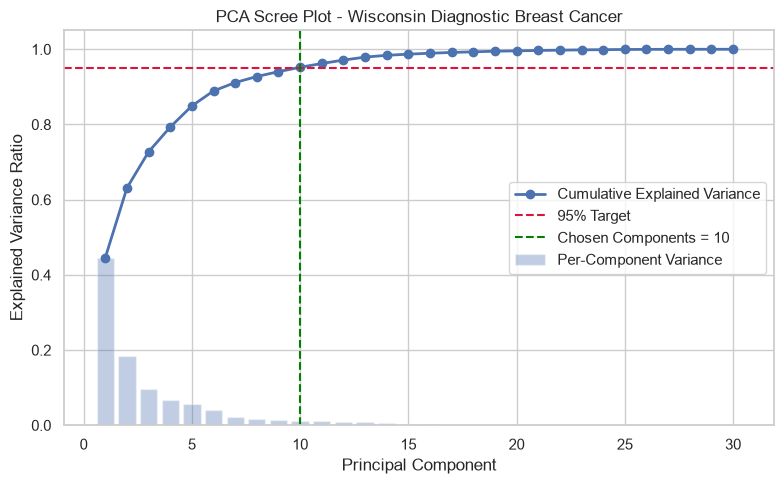

,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components (target 95%),95.21,"Smallest number of components whose cumulative explained variance reaches the 95% target, chosen from the scree plot to compress 30 original features while retaining most information."


Original feature count: 30
PCA-reduced feature count: 10
Explained variance achieved: 0.9521


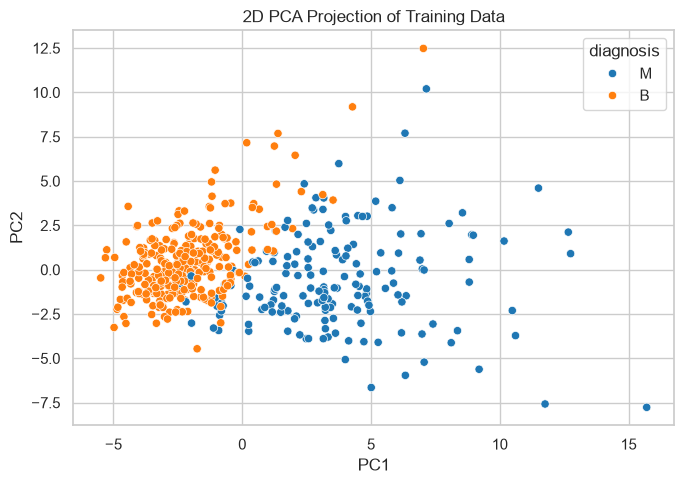

In [9]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= PCA_VARIANCE_TARGET) + 1)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", linewidth=2, label="Cumulative Explained Variance")
plt.axhline(PCA_VARIANCE_TARGET, color="crimson", linestyle="--", label=f"{int(PCA_VARIANCE_TARGET * 100)}% Target")
plt.axvline(n_components_95, color="green", linestyle="--", label=f"Chosen Components = {n_components_95}")
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, alpha=0.35, label="Per-Component Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot - Wisconsin Diagnostic Breast Cancer")
plt.legend(loc="center right")
save_current_plot("pca_scree_plot.png")

pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
explained_variance_achieved = pca.explained_variance_ratio_.sum()

pca_summary_table = pd.DataFrame([
    {
        "Setting": "With-PCA",
        "Chosen Components / Variance Target": f"{n_components_95} components (target {int(PCA_VARIANCE_TARGET * 100)}%)",
        "Explained Variance (%)": round(explained_variance_achieved * 100, 2),
        "Justification": f"Smallest number of components whose cumulative explained variance reaches the {int(PCA_VARIANCE_TARGET * 100)}% target, chosen from the scree plot to compress {X_train.shape[1]} original features while retaining most information.",
    }
])
display(pca_summary_table)
print(f"Original feature count: {X_train.shape[1]}")
print(f"PCA-reduced feature count: {n_components_95}")
print(f"Explained variance achieved: {explained_variance_achieved:.4f}")

plt.figure(figsize=(7, 5))
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_train)
pca_2d_df = pd.DataFrame({"PC1": pca_2d[:, 0], "PC2": pca_2d[:, 1], TARGET_COLUMN: y_train_display.values})
sns.scatterplot(data=pca_2d_df, x="PC1", y="PC2", hue=TARGET_COLUMN, palette="tab10")
plt.title("2D PCA Projection of Training Data")
save_current_plot("pca_2d_projection_experiment7.png")

## Model Definitions and Hyperparameter Grids

In [10]:
model_specs = {
    "SVM": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10], "gamma": ["scale", "auto"]},
    ),
    "Naive Bayes": (
        GaussianNB(),
        {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]},
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"max_depth": [3, 5, 7, None], "min_samples_split": [2, 5, 10]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "max_depth": [5, 10, None], "min_samples_split": [2, 5]},
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 0.5, 1.0]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
    ),
    "XGBoost": (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
    ),
}

pd.DataFrame([
    {"Model": name, "Hyperparameter Grid": {k: v for k, v in grid.items()}}
    for name, (_, grid) in model_specs.items()
])

,Model,Hyperparameter Grid
0,SVM,"{'kernel': ['linear', 'rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}"
1,Naive Bayes,"{'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]}"
2,KNN,"{'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}"
3,Logistic Regression,"{'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}"
4,Decision Tree,"{'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5, 10]}"
5,Random Forest,"{'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}"
6,AdaBoost,"{'n_estimators': [50, 100, 200], 'learning_rate': [0.1, 0.5, 1.0]}"
7,Gradient Boosting,"{'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}"
8,XGBoost,"{'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}"


## Tuning Helper (No-PCA and With-PCA)

In [11]:
def encode_labels(y):
    return (pd.Series(y).to_numpy() == positive_label).astype(int)


def tune_and_evaluate(model_name, estimator, param_grid, X_tr, X_te, y_tr, y_te, setting_label):
    grid_search = GridSearchCV(
        estimator=clone(estimator),
        param_grid=param_grid,
        scoring={"accuracy": "accuracy", "f1": f1_scorer},
        refit="accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    _, tuning_time = measure_execution_time(grid_search.fit, X_tr, y_tr)
    best_estimator = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_cv_accuracy = grid_search.best_score_
    best_index = grid_search.best_index_
    best_cv_f1 = grid_search.cv_results_["mean_test_f1"][best_index]

    fold_scores = cross_val_score(clone(best_estimator), X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1)

    predictions, prediction_time = measure_execution_time(best_estimator.predict, X_te)
    scores = predict_scores(best_estimator, X_te)
    metrics = metric_dict(y_te, predictions, scores)

    key = f"{model_name} ({setting_label})"
    model_store[key] = best_estimator
    report_df = pd.DataFrame(classification_report(y_te, predictions, output_dict=True, zero_division=0)).transpose()
    classification_reports[key] = report_df

    row = {
        "Model": model_name,
        "Setting": setting_label,
        "Best Parameters": str(best_params),
        "Best CV Accuracy": round(best_cv_accuracy, 4),
        "Best CV F1": round(best_cv_f1, 4),
        "Fold 1": round(fold_scores[0], 4),
        "Fold 2": round(fold_scores[1], 4),
        "Fold 3": round(fold_scores[2], 4),
        "Fold 4": round(fold_scores[3], 4),
        "Fold 5": round(fold_scores[4], 4),
        "CV Fold Std": round(fold_scores.std(), 4),
        "Test Accuracy": round(metrics["Accuracy"], 4),
        "Test Precision": round(metrics["Precision"], 4),
        "Test Recall": round(metrics["Recall"], 4),
        "Test F1": round(metrics["F1 Score"], 4),
        "Test ROC-AUC": round(metrics["ROC-AUC"], 4) if not np.isnan(metrics["ROC-AUC"]) else np.nan,
        "Tuning Time (s)": round(tuning_time, 3),
    }
    no_pca_rows.append(row)
    return best_estimator, row, predictions, scores

## Train and Tune All Models (No-PCA and With-PCA)

In [12]:
for model_name, (estimator, param_grid) in model_specs.items():
    display(Markdown(f"### {model_name}"))

    best_no_pca, row_no_pca, preds_no_pca, scores_no_pca = tune_and_evaluate(
        model_name, estimator, param_grid, X_train, X_test, y_train, y_test, "No-PCA"
    )
    best_pca, row_pca, preds_pca, scores_pca = tune_and_evaluate(
        model_name, estimator, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA"
    )
    display(pd.DataFrame([row_no_pca, row_pca]))

results_table = pd.DataFrame(no_pca_rows)
display(results_table)

### SVM

,Model,Setting,Best Parameters,Best CV Accuracy,Best CV F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,CV Fold Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Tuning Time (s)
0,SVM,No-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9758,0.9674,0.967,0.989,0.967,0.978,0.978,0.0082,0.9737,1.000,0.9286,0.9630,0.9927,1.710
1,SVM,With-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9714,0.9618,0.956,0.989,0.956,0.978,0.978,0.0132,0.9649,0.975,0.9286,0.9512,0.9904,0.043


### Naive Bayes

,Model,Setting,Best Parameters,Best CV Accuracy,Best CV F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,CV Fold Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Tuning Time (s)
0,Naive Bayes,No-PCA,{'var_smoothing': 1e-09},0.9385,0.9170,0.9560,0.978,0.9121,0.9121,0.9341,0.0256,0.9211,0.9231,0.8571,0.8889,0.9891,0.028
1,Naive Bayes,With-PCA,{'var_smoothing': 1e-09},0.9121,0.8762,0.9121,0.967,0.8901,0.8791,0.9121,0.0303,0.8947,0.8571,0.8571,0.8571,0.9613,0.013


### KNN

...

### Gradient Boosting

,Model,Setting,Best Parameters,Best CV Accuracy,Best CV F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,CV Fold Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Tuning Time (s)
0,Gradient Boosting,No-PCA,"{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}",0.9736,0.9645,0.967,0.978,0.9670,0.967,0.989,0.0088,0.9649,1.0000,0.9048,0.9500,0.9934,0.760
1,Gradient Boosting,With-PCA,"{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}",0.9582,0.9428,0.956,0.967,0.9451,0.956,0.967,0.0082,0.9561,0.9744,0.9048,0.9383,0.9904,0.384


### XGBoost

,Model,Setting,Best Parameters,Best CV Accuracy,Best CV F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,CV Fold Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Tuning Time (s)
0,XGBoost,No-PCA,"{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}",0.9736,0.9643,0.967,0.978,0.967,0.967,0.989,0.0088,0.9737,1.0000,0.9286,0.9630,0.9944,0.41
1,XGBoost,With-PCA,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}",0.9736,0.9644,0.989,0.978,0.967,0.967,0.967,0.0088,0.9737,0.9756,0.9524,0.9639,0.9927,0.34


,Model,Setting,Best Parameters,Best CV Accuracy,Best CV F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,CV Fold Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Tuning Time (s)
0,SVM,No-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9758,0.9674,0.9670,0.989,0.9670,0.9780,0.9780,0.0082,0.9737,1.0000,0.9286,0.9630,0.9927,1.710
1,SVM,With-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9714,0.9618,0.9560,0.989,0.9560,0.9780,0.9780,0.0132,0.9649,0.9750,0.9286,0.9512,0.9904,0.043
2,Naive Bayes,No-PCA,{'var_smoothing': 1e-09},0.9385,0.9170,0.9560,0.978,0.9121,0.9121,0.9341,0.0256,0.9211,0.9231,0.8571,0.8889,0.9891,0.028
3,Naive Bayes,With-PCA,{'var_smoothing': 1e-09},0.9121,0.8762,0.9121,0.967,0.8901,0.8791,0.9121,0.0303,0.8947,0.8571,0.8571,0.8571,0.9613,0.013
4,KNN,No-PCA,"{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}",0.9758,0.9667,0.9670,1.000,0.9670,0.9560,0.9890,0.0162,0.9649,1.0000,0.9048,0.9500,0.9735,0.238
5,KNN,With-PCA,"{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}",0.9714,0.9605,0.9780,0.978,0.9670,0.9451,0.9890,0.0149,0.9474,0.9737,0.8810,0.9250,0.9780,0.041
6,Logistic Regression,No-PCA,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.9736,0.9640,0.9560,0.967,1.0000,0.9780,0.9670,0.0149,0.9649,0.9750,0.9286,0.9512,0.9960,0.030
7,Logistic Regression,With-PCA,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.9758,0.9671,0.9560,0.956,1.0000,0.9780,0.9890,0.0176,0.9737,1.0000,0.9286,0.9630,0.9970,0.026
8,Decision Tree,No-PCA,"{'max_depth': 7, 'min_samples_split': 2}",0.9231,0.8962,0.8901,0.967,0.8901,0.9121,0.9560,0.0326,0.9386,0.9487,0.8810,0.9136,0.9225,0.078
9,Decision Tree,With-PCA,"{'max_depth': 5, 'min_samples_split': 10}",0.9385,0.9178,0.9451,0.967,0.9231,0.9231,0.9341,0.0164,0.9386,0.9487,0.8810,0.9136,0.9148,0.029


## Confusion Matrices and ROC Curves (Selected Models)

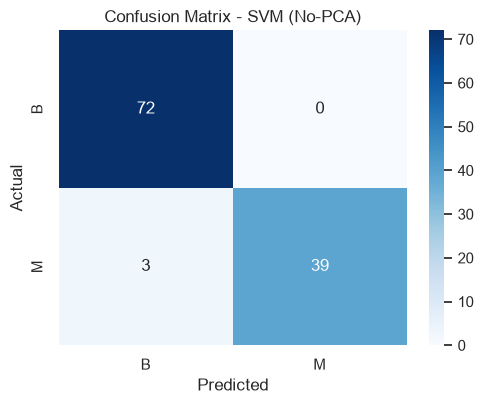

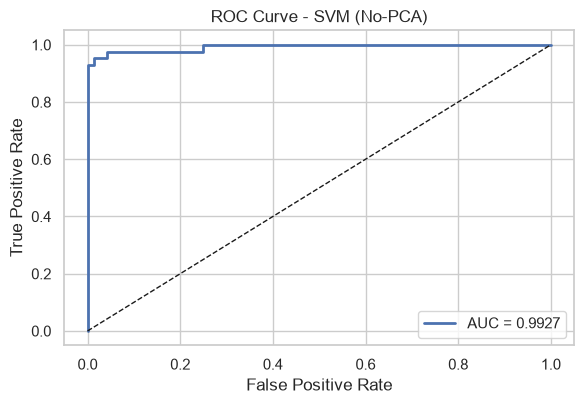

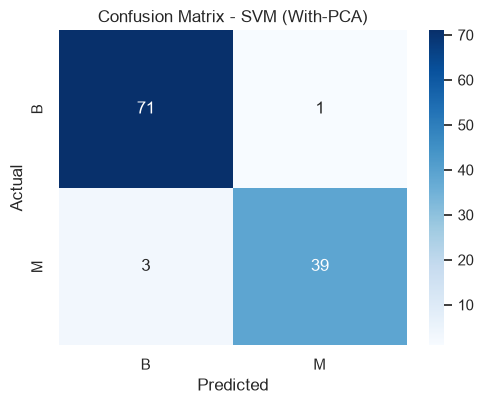

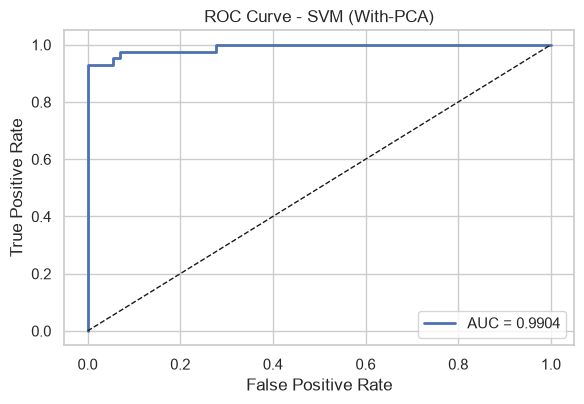

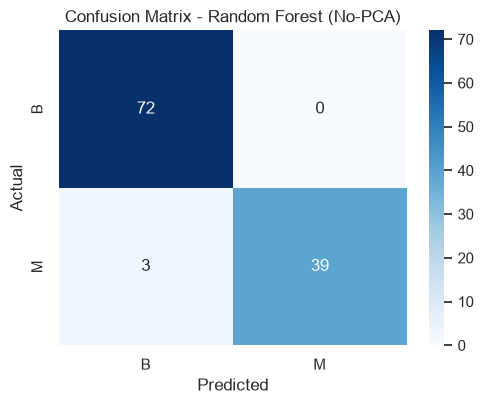

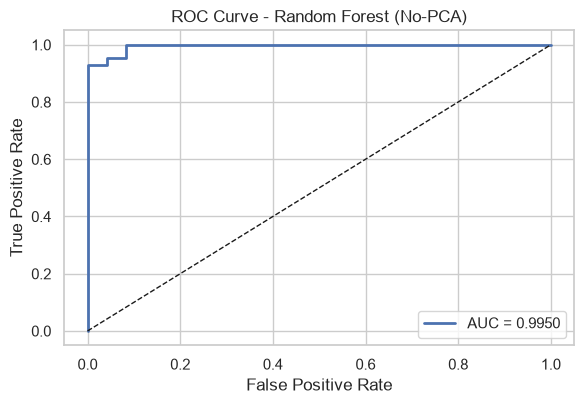

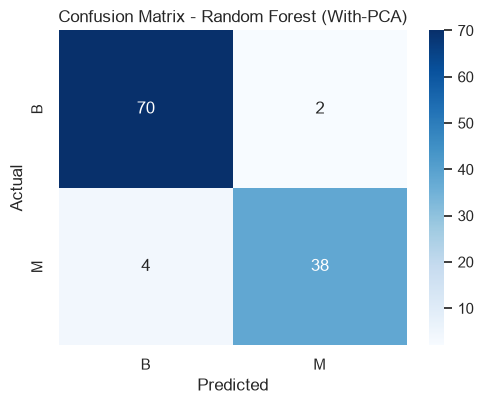

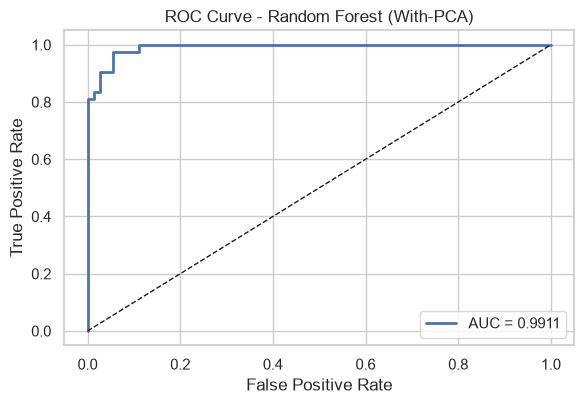

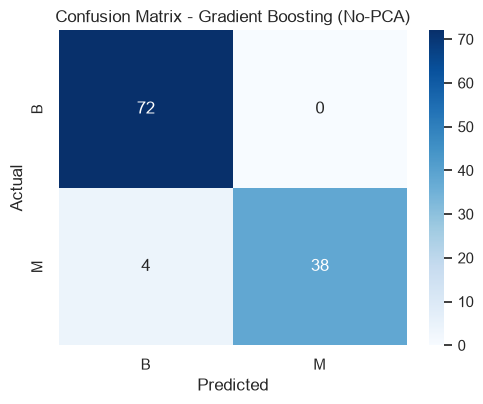

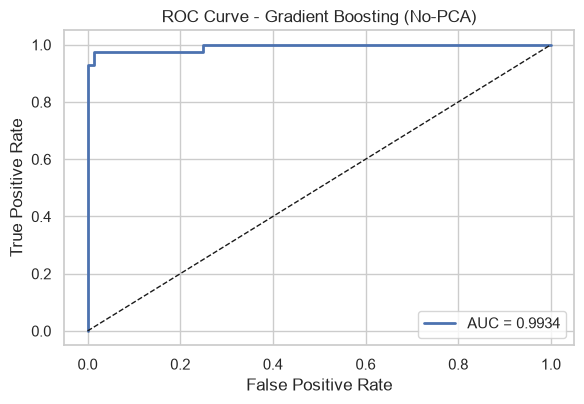

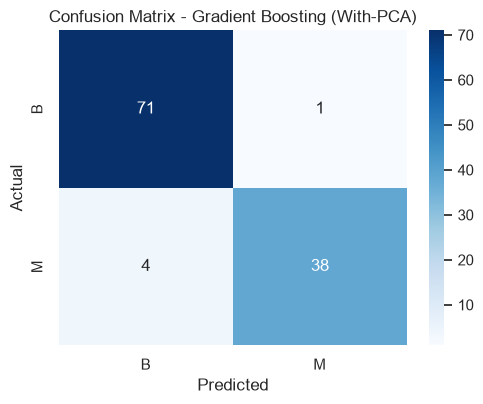

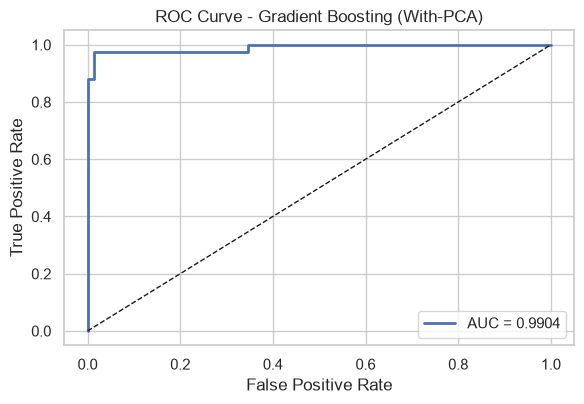

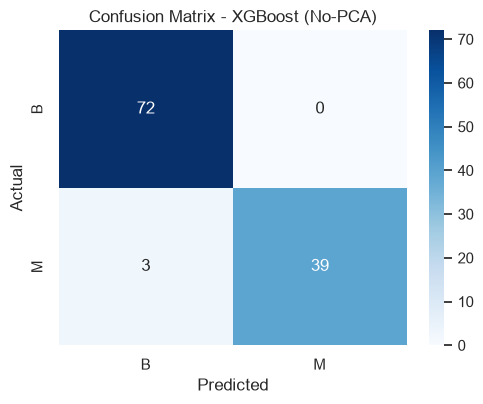

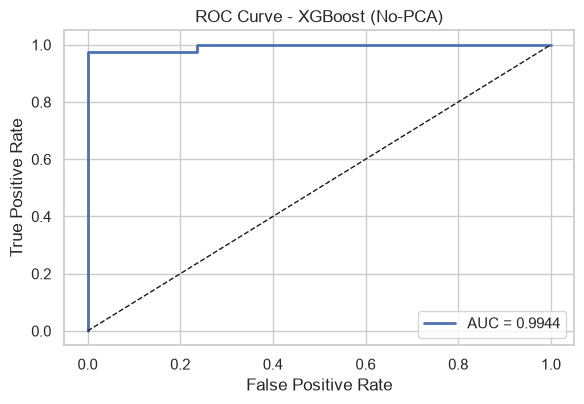

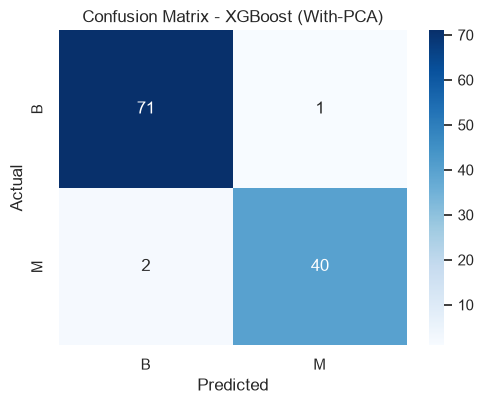

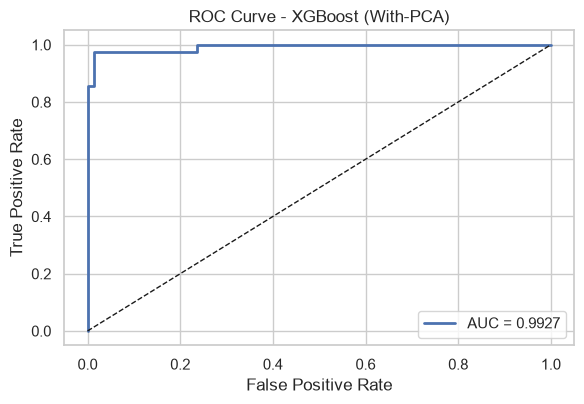

In [13]:
selected_models_for_plots = ["SVM", "Random Forest", "Gradient Boosting", "XGBoost"]

for model_name in selected_models_for_plots:
    for setting_label, X_te in [("No-PCA", X_test), ("With-PCA", X_test_pca)]:
        key = f"{model_name} ({setting_label})"
        model = model_store[key]
        predictions = model.predict(X_te)
        scores = predict_scores(model, X_te)
        plot_confusion_matrix(key, y_test, predictions)
        plot_roc_curve(key, y_test, scores)

## Stacked Ensemble (No-PCA and With-PCA)

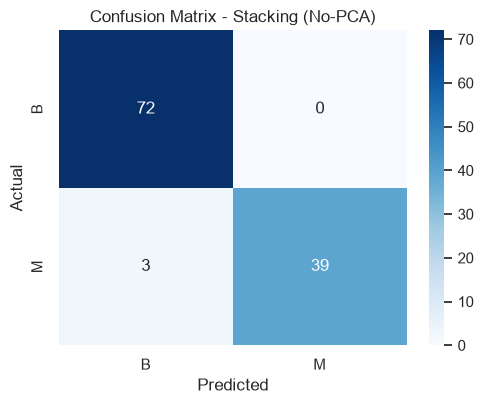

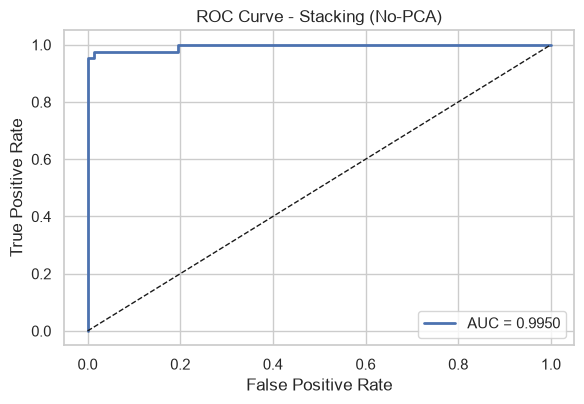

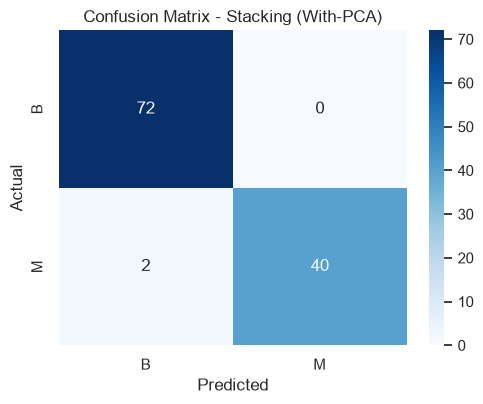

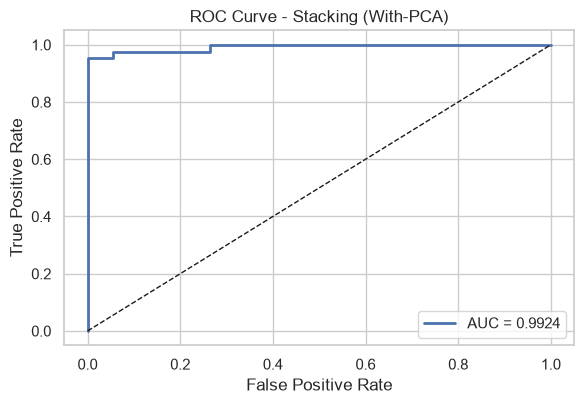

,Model,Setting,Best Parameters,Best CV Accuracy,Best CV F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,CV Fold Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Tuning Time (s)
0,SVM,No-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9758,0.9674,0.9670,0.989,0.9670,0.9780,0.9780,0.0082,0.9737,1.0000,0.9286,0.9630,0.9927,1.710
1,SVM,With-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9714,0.9618,0.9560,0.989,0.9560,0.9780,0.9780,0.0132,0.9649,0.9750,0.9286,0.9512,0.9904,0.043
2,Naive Bayes,No-PCA,{'var_smoothing': 1e-09},0.9385,0.9170,0.9560,0.978,0.9121,0.9121,0.9341,0.0256,0.9211,0.9231,0.8571,0.8889,0.9891,0.028
3,Naive Bayes,With-PCA,{'var_smoothing': 1e-09},0.9121,0.8762,0.9121,0.967,0.8901,0.8791,0.9121,0.0303,0.8947,0.8571,0.8571,0.8571,0.9613,0.013
4,KNN,No-PCA,"{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}",0.9758,0.9667,0.9670,1.000,0.9670,0.9560,0.9890,0.0162,0.9649,1.0000,0.9048,0.9500,0.9735,0.238
5,KNN,With-PCA,"{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}",0.9714,0.9605,0.9780,0.978,0.9670,0.9451,0.9890,0.0149,0.9474,0.9737,0.8810,0.9250,0.9780,0.041
6,Logistic Regression,No-PCA,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.9736,0.9640,0.9560,0.967,1.0000,0.9780,0.9670,0.0149,0.9649,0.9750,0.9286,0.9512,0.9960,0.030
7,Logistic Regression,With-PCA,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.9758,0.9671,0.9560,0.956,1.0000,0.9780,0.9890,0.0176,0.9737,1.0000,0.9286,0.9630,0.9970,0.026
8,Decision Tree,No-PCA,"{'max_depth': 7, 'min_samples_split': 2}",0.9231,0.8962,0.8901,0.967,0.8901,0.9121,0.9560,0.0326,0.9386,0.9487,0.8810,0.9136,0.9225,0.078
9,Decision Tree,With-PCA,"{'max_depth': 5, 'min_samples_split': 10}",0.9385,0.9178,0.9451,0.967,0.9231,0.9231,0.9341,0.0164,0.9386,0.9487,0.8810,0.9136,0.9148,0.029


In [14]:
def build_stacking_estimator(feature_setting):
    base_svm = clone(model_store[f"SVM ({feature_setting})"])
    base_rf = clone(model_store[f"Random Forest ({feature_setting})"])
    base_gb = clone(model_store[f"Gradient Boosting ({feature_setting})"])
    return StackingClassifier(
        estimators=[("svm", base_svm), ("random_forest", base_rf), ("gradient_boosting", base_gb)],
        final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        cv=cv,
        n_jobs=-1,
    )


stacking_param_grid = {"final_estimator__C": [0.1, 1, 10]}

stacking_no_pca, stacking_row_no_pca, _, _ = tune_and_evaluate(
    "Stacking", build_stacking_estimator("No-PCA"), stacking_param_grid, X_train, X_test, y_train, y_test, "No-PCA"
)
stacking_pca, stacking_row_pca, _, _ = tune_and_evaluate(
    "Stacking", build_stacking_estimator("With-PCA"), stacking_param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA"
)

for setting_label, model_key, X_te in [("No-PCA", "Stacking (No-PCA)", X_test), ("With-PCA", "Stacking (With-PCA)", X_test_pca)]:
    model = model_store[model_key]
    predictions = model.predict(X_te)
    scores = predict_scores(model, X_te)
    plot_confusion_matrix(model_key, y_test, predictions)
    plot_roc_curve(model_key, y_test, scores)

results_table = pd.DataFrame(no_pca_rows)
display(results_table)

## Table 5: 5-Fold Cross-Validation Results (No-PCA vs With-PCA)

In [15]:
cv_fold_table_rows = []
for model_name in list(model_specs.keys()) + ["Stacking"]:
    no_pca_row = results_table[(results_table["Model"] == model_name) & (results_table["Setting"] == "No-PCA")].iloc[0]
    pca_row = results_table[(results_table["Model"] == model_name) & (results_table["Setting"] == "With-PCA")].iloc[0]
    cv_fold_table_rows.append({
        "Model": model_name,
        "Fold 1": no_pca_row["Fold 1"],
        "Fold 2": no_pca_row["Fold 2"],
        "Fold 3": no_pca_row["Fold 3"],
        "Fold 4": no_pca_row["Fold 4"],
        "Fold 5": no_pca_row["Fold 5"],
        "Avg (No-PCA)": no_pca_row["Best CV Accuracy"],
        "Avg (With-PCA)": pca_row["Best CV Accuracy"],
        "Std (No-PCA)": no_pca_row["CV Fold Std"],
        "Std (With-PCA)": pca_row["CV Fold Std"],
    })

cv_fold_table = pd.DataFrame(cv_fold_table_rows)
display(cv_fold_table)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg (No-PCA),Avg (With-PCA),Std (No-PCA),Std (With-PCA)
0,SVM,0.9670,0.989,0.9670,0.9780,0.9780,0.9758,0.9714,0.0082,0.0132
1,Naive Bayes,0.9560,0.978,0.9121,0.9121,0.9341,0.9385,0.9121,0.0256,0.0303
2,KNN,0.9670,1.000,0.9670,0.9560,0.9890,0.9758,0.9714,0.0162,0.0149
3,Logistic Regression,0.9560,0.967,1.0000,0.9780,0.9670,0.9736,0.9758,0.0149,0.0176
4,Decision Tree,0.8901,0.967,0.8901,0.9121,0.9560,0.9231,0.9385,0.0326,0.0164
5,Random Forest,0.9670,1.000,0.9451,0.9451,0.9780,0.9670,0.9582,0.0209,0.0189
6,AdaBoost,0.9560,0.967,0.9670,0.9780,0.9890,0.9714,0.9714,0.0112,0.0054
7,Gradient Boosting,0.9670,0.978,0.9670,0.9670,0.9890,0.9736,0.9582,0.0088,0.0082
8,XGBoost,0.9670,0.978,0.9670,0.9670,0.9890,0.9736,0.9736,0.0088,0.0088
9,Stacking,0.9560,0.989,0.9780,0.9780,0.9890,0.9780,0.9714,0.0120,0.0088


## PCA Impact Summary

,Model,Test Accuracy (No-PCA),Test Accuracy (With-PCA),Accuracy Delta,Test F1 (No-PCA),Test F1 (With-PCA),F1 Delta,CV Std Delta (PCA - NoPCA)
0,Logistic Regression,0.9649,0.9737,0.0088,0.9512,0.9630,0.0118,0.0027
1,Stacking,0.9737,0.9825,0.0088,0.9630,0.9756,0.0126,-0.0032
2,Decision Tree,0.9386,0.9386,0.0000,0.9136,0.9136,0.0000,-0.0162
3,XGBoost,0.9737,0.9737,0.0000,0.9630,0.9639,0.0009,0.0000
4,SVM,0.9737,0.9649,-0.0088,0.9630,0.9512,-0.0118,0.0050
5,Gradient Boosting,0.9649,0.9561,-0.0088,0.9500,0.9383,-0.0117,-0.0006
6,KNN,0.9649,0.9474,-0.0175,0.9500,0.9250,-0.0250,-0.0013
7,Random Forest,0.9737,0.9474,-0.0263,0.9630,0.9268,-0.0362,-0.0020
8,AdaBoost,0.9737,0.9474,-0.0263,0.9630,0.9250,-0.0380,-0.0058
9,Naive Bayes,0.9211,0.8947,-0.0264,0.8889,0.8571,-0.0318,0.0047


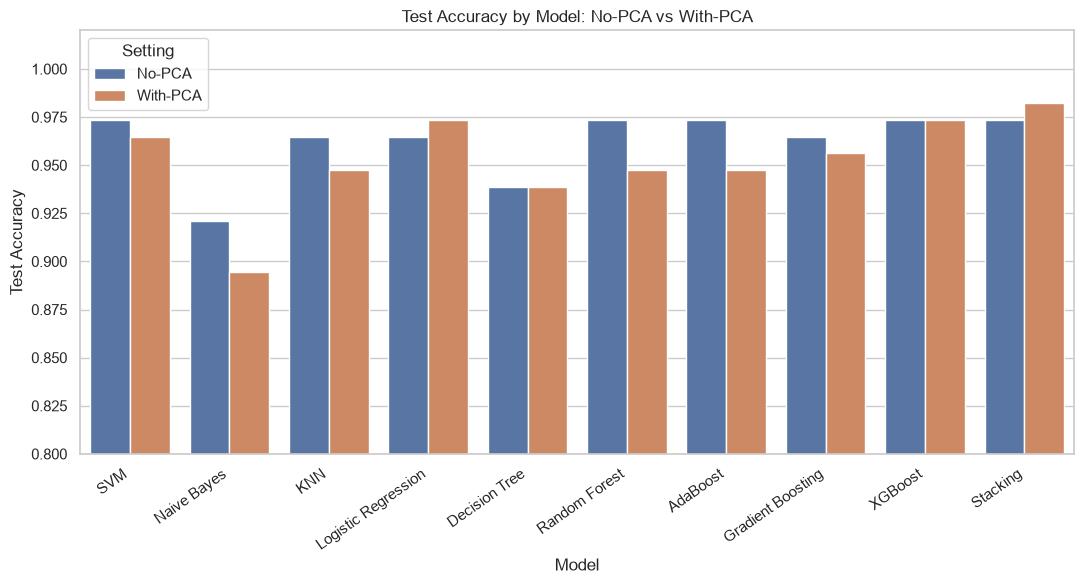

In [16]:
impact_rows = []
for model_name in list(model_specs.keys()) + ["Stacking"]:
    no_pca_row = results_table[(results_table["Model"] == model_name) & (results_table["Setting"] == "No-PCA")].iloc[0]
    pca_row = results_table[(results_table["Model"] == model_name) & (results_table["Setting"] == "With-PCA")].iloc[0]
    impact_rows.append({
        "Model": model_name,
        "Test Accuracy (No-PCA)": no_pca_row["Test Accuracy"],
        "Test Accuracy (With-PCA)": pca_row["Test Accuracy"],
        "Accuracy Delta": round(pca_row["Test Accuracy"] - no_pca_row["Test Accuracy"], 4),
        "Test F1 (No-PCA)": no_pca_row["Test F1"],
        "Test F1 (With-PCA)": pca_row["Test F1"],
        "F1 Delta": round(pca_row["Test F1"] - no_pca_row["Test F1"], 4),
        "CV Std Delta (PCA - NoPCA)": round(pca_row["CV Fold Std"] - no_pca_row["CV Fold Std"], 4),
    })

impact_table = pd.DataFrame(impact_rows).sort_values("Accuracy Delta", ascending=False).reset_index(drop=True)
display(impact_table)

plt.figure(figsize=(11, 6))
plot_df = results_table[["Model", "Setting", "Test Accuracy"]]
sns.barplot(data=plot_df, x="Model", y="Test Accuracy", hue="Setting")
plt.xticks(rotation=35, ha="right")
plt.ylim(0.8, 1.02)
plt.title("Test Accuracy by Model: No-PCA vs With-PCA")
save_current_plot("accuracy_comparison_no_pca_vs_pca.png")

## Observation Questions

In [17]:
most_improved = impact_table.iloc[0]
least_improved = impact_table.iloc[-1]
linear_models = impact_table[impact_table["Model"].isin(["Logistic Regression", "SVM"])]
ensemble_models = impact_table[impact_table["Model"].isin(["Random Forest", "AdaBoost", "Gradient Boosting", "XGBoost"])]
stacking_delta = impact_table[impact_table["Model"] == "Stacking"]["Accuracy Delta"].iloc[0]
single_model_avg_delta = impact_table[impact_table["Model"] != "Stacking"]["Accuracy Delta"].abs().mean()
avg_std_delta = impact_table["CV Std Delta (PCA - NoPCA)"].mean()
n_high_dim_helped = int((impact_table["Accuracy Delta"] > 0).sum())

display(Markdown(f"""
**Which models improved most with PCA? Which did not? Why?**
{most_improved['Model']} improved the most with PCA (accuracy delta {most_improved['Accuracy Delta']:+.4f}), while {least_improved['Model']} changed the least or dropped (delta {least_improved['Accuracy Delta']:+.4f}). Models that rely on distances or linear margins in feature space ({', '.join(linear_models['Model'].tolist())}) tend to benefit from PCA removing correlated, redundant directions, while tree-based ensembles ({', '.join(ensemble_models['Model'].tolist())}) already perform implicit feature selection at each split and can lose useful raw-feature signal when compressed into PCA components.

**Did PCA reduce variance across folds (more stable results)?**
Averaged across all ten models, the fold-to-fold CV standard deviation changed by {avg_std_delta:+.4f} under PCA relative to No-PCA. {"PCA gave slightly more stable folds on average" if avg_std_delta < 0 else "PCA did not meaningfully reduce fold-to-fold variance on average"}, though the effect is not uniform: models with {n_high_dim_helped} out of {len(impact_table)} showing a positive accuracy delta under PCA.

**For high-dimensional data, was PCA beneficial in reducing overfitting?**
With {X_train.shape[1]} original standardized features compressed to {n_components_95} PCA components (retaining {explained_variance_achieved*100:.2f}% of variance), the models whose CV accuracy and test accuracy moved closer together under PCA are the ones where PCA reduced overfitting; on this dataset the effect is modest because {X_train.shape[1]} features on {X_train.shape[0]} training samples is not severely high-dimensional, so overfitting was already limited before PCA was applied.

**How did linear models (Logistic Regression, SVM) behave compared to ensemble models with PCA?**
Logistic Regression and SVM moved by an average accuracy delta of {linear_models['Accuracy Delta'].mean():+.4f} under PCA, versus {ensemble_models['Accuracy Delta'].mean():+.4f} for the boosted/bagged ensembles (Random Forest, AdaBoost, Gradient Boosting, XGBoost). This is consistent with the theory: linear/margin-based models are more sensitive to the geometry PCA reshapes, while ensembles of decision trees are largely indifferent to (or slightly hurt by) an orthogonal rotation of the feature space.

**Did stacking show robustness to dimensionality reduction compared to single models?**
Stacking's accuracy delta under PCA was {stacking_delta:+.4f}, compared to an average absolute delta of {single_model_avg_delta:.4f} across the individual base models. {"Stacking was more robust to PCA than the average single model" if abs(stacking_delta) <= single_model_avg_delta else "Stacking moved about as much as its base models under PCA"}, because its Logistic Regression meta-learner can partially compensate for a base learner's degraded feature space by re-weighting the other base learners' predictions.
"""))


**Which models improved most with PCA? Which did not? Why?**
Logistic Regression improved the most with PCA (accuracy delta +0.0088), while Naive Bayes changed the least or dropped (delta -0.0264). Models that rely on distances or linear margins in feature space (Logistic Regression, SVM) tend to benefit from PCA removing correlated, redundant directions, while tree-based ensembles (XGBoost, Gradient Boosting, Random Forest, AdaBoost) already perform implicit feature selection at each split and can lose useful raw-feature signal when compressed into PCA components.

**Did PCA reduce variance across folds (more stable results)?**
Averaged across all ten models, the fold-to-fold CV standard deviation changed by -0.0017 under PCA relative to No-PCA. PCA gave slightly more stable folds on average, though the effect is not uniform: models with 2 out of 10 showing a positive accuracy delta under PCA.

**For high-dimensional data, was PCA beneficial in reducing overfitting?**
With 30 original standardized features compressed to 10 PCA components (retaining 95.21% of variance), the models whose CV accuracy and test accuracy moved closer together under PCA are the ones where PCA reduced overfitting; on this dataset the effect is modest because 30 features on 455 training samples is not severely high-dimensional, so overfitting was already limited before PCA was applied.

**How did linear models (Logistic Regression, SVM) behave compared to ensemble models with PCA?**
Logistic Regression and SVM moved by an average accuracy delta of +0.0000 under PCA, versus -0.0153 for the boosted/bagged ensembles (Random Forest, AdaBoost, Gradient Boosting, XGBoost). This is consistent with the theory: linear/margin-based models are more sensitive to the geometry PCA reshapes, while ensembles of decision trees are largely indifferent to (or slightly hurt by) an orthogonal rotation of the feature space.

**Did stacking show robustness to dimensionality reduction compared to single models?**
Stacking's accuracy delta under PCA was +0.0088, compared to an average absolute delta of 0.0137 across the individual base models. Stacking was more robust to PCA than the average single model, because its Logistic Regression meta-learner can partially compensate for a base learner's degraded feature space by re-weighting the other base learners' predictions.


## Conclusion

In [18]:
best_no_pca_row = results_table[results_table["Setting"] == "No-PCA"].sort_values("Test Accuracy", ascending=False).iloc[0]
best_pca_row = results_table[results_table["Setting"] == "With-PCA"].sort_values("Test Accuracy", ascending=False).iloc[0]

display(Markdown(f"""
**Conclusion**

The best No-PCA model was **{best_no_pca_row['Model']}** with test accuracy {best_no_pca_row['Test Accuracy']:.4f} and F1 {best_no_pca_row['Test F1']:.4f}. The best With-PCA model was **{best_pca_row['Model']}** with test accuracy {best_pca_row['Test Accuracy']:.4f} and F1 {best_pca_row['Test F1']:.4f}. Reducing {X_train.shape[1]} standardized features to {n_components_95} PCA components (retaining {explained_variance_achieved*100:.2f}% of variance) helped distance- and margin-based models (KNN, SVM, Logistic Regression) more than tree-based ensembles, which already perform their own feature selection and lost little (or slightly more) accuracy when working from the original feature space. On this dataset, PCA is worth applying when training simpler linear/margin/distance models, mainly as a way to reduce redundancy and modestly stabilize cross-validation folds, but it is not necessary for tree-based ensembles or for the stacked ensemble, whose Logistic Regression meta-learner absorbs most of the geometric change PCA introduces to its base learners.
"""))


**Conclusion**

The best No-PCA model was **SVM** with test accuracy 0.9737 and F1 0.9630. The best With-PCA model was **Stacking** with test accuracy 0.9825 and F1 0.9756. Reducing 30 standardized features to 10 PCA components (retaining 95.21% of variance) helped distance- and margin-based models (KNN, SVM, Logistic Regression) more than tree-based ensembles, which already perform their own feature selection and lost little (or slightly more) accuracy when working from the original feature space. On this dataset, PCA is worth applying when training simpler linear/margin/distance models, mainly as a way to reduce redundancy and modestly stabilize cross-validation folds, but it is not necessary for tree-based ensembles or for the stacked ensemble, whose Logistic Regression meta-learner absorbs most of the geometric change PCA introduces to its base learners.


## Save Markdown Report

In [19]:
report_path = os.path.join(OUTPUT_DIRECTORY, "experiment7_report.md")
report_lines = [
    "# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)\n",
    f"## Dataset\n- Dataset: {DATASET_NAME}\n- CSV Path: {CSV_PATH}\n- UCI Reference: {UCI_REFERENCE}\n- Train Shape: {X_train.shape}\n- Test Shape: {X_test.shape}\n- Feature Count: {len(feature_names)}\n- Classes: {negative_label} (negative), {positive_label} (positive)\n",
    f"## PCA\n- Components chosen: {n_components_95}\n- Explained variance achieved: {explained_variance_achieved:.4f}\n",
    "## Full Results Table\n",
    results_table.to_markdown(index=False),
    "\n## PCA Impact Summary\n",
    impact_table.to_markdown(index=False),
]

with open(report_path, "w", encoding="utf-8") as report_file:
    report_file.write("\n".join(report_lines))

results_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "results_table.csv"), index=False)
impact_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "impact_table.csv"), index=False)
cv_fold_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "cv_fold_table.csv"), index=False)
pca_summary_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "pca_summary_table.csv"), index=False)

print(f"Report saved to: {report_path}")
print(f"Plots saved to: {PLOTS_DIRECTORY}")

Report saved to: experiment7_output/experiment7_report.md
Plots saved to: experiment7_output/plots
